In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
import itertools

# Спрос на велосипеды

В этой домашке мы будем работать с данными о спросе на велосипеды. Мы научимся его предсказывать.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/hse-econ-data-science/andan2024/main/hw/data/bikes_rent.csv')
print(df.shape)
df.head()

(731, 13)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


__Описание переменных:__

* `season`  1 - весна, 2 - лето, 3 - осень, 4 - зима
* `yr`  0 - 2011, 1 - 2012
* `mnth`  от 1 до 12
* `holiday`  0 - нет праздника, 1 - есть праздник
* `weekday`  от 0 до 6
* `workingday`  0 - нерабочий день, 1 - рабочий день
* `weathersit`  оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
* `temp`  температура в Цельсиях
* `atemp`  температура по ощущениям в Цельсиях
* `hum`  влажность
* `windspeed(mph)`  скорость ветра в милях в час
* `windspeed(ms)`  скорость ветра в метрах в секунду
* `cnt`  количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

In [ ]:
# Функция для того, чтобы на одной картинке смотреть те графики с прогнозами.
def plot_yreal_ypred(y_test, y_train, y_test_hat, y_train_hat):
    """
        Рисует картинку для прогнозов регрессии
    """

    margin = 0.1 # отступ на границах
    plt.figure(figsize=(10,5))
    plt.subplot(121)
    plt.scatter(y_train, y_train_hat, color="red", alpha=0.5)
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.axis('equal')
    plt.axis('square')
    train_min = min(y_train)
    train_max = max(y_train)
    plt.xlim(train_min - margin, train_max + margin)
    plt.ylim(train_min - margin, train_max + margin)
    plt.plot([-10000, 10000], [-10000, 10000])
    plt.title('Train set', fontsize=20)

    plt.subplot(122)
    plt.scatter(y_test, y_test_hat, color="red", alpha=0.5)
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.axis('equal')
    plt.axis('square')
    test_min = min(y_test)
    test_max = max(y_test)
    plt.xlim(test_min - margin, test_max + margin)
    plt.ylim(test_min - margin, test_max + margin)
    plt.plot([-10000, 10000], [-10000, 10000])
    plt.title('Test set', fontsize=20)
    pass

## 1. EDA

__а) [5 баллов]__ Проверьте, есть ли в данных пропуски

In [ ]:
# в тексте нет пропусков
df.isna().sum()

season            0
yr                0
mnth              0
holiday           0
weekday           0
workingday        0
weathersit        0
temp              0
atemp             0
hum               0
windspeed(mph)    0
windspeed(ms)     0
cnt               0
dtype: int64

__б) [5 баллов]__ Составьте список из категориальных переменных и список из действительных переменных.

In [ ]:
var_cat = np.array(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit'])

var_real = np.array(['temp', 'atemp', 'hum', 'windspeed(mph)', 'windspeed(ms)'])

target = 'cnt'

__в) [5 баллов]__ Нарисуйте гистограмму для целевого признака. Что можете сказать о его хвосте? Надо ли предпринять какие-нибудь манипуляции, связанные с борьбой с выбросами?

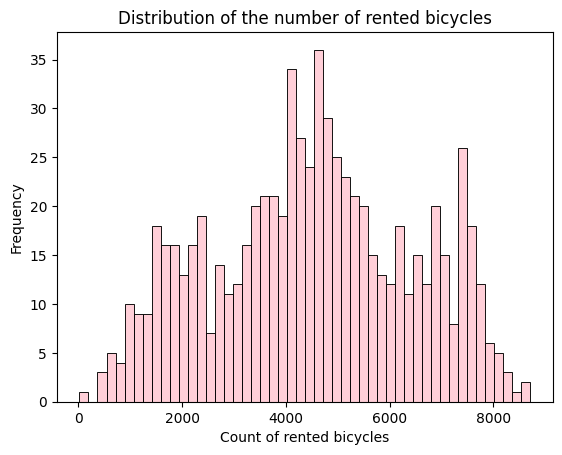

In [ ]:
sns.histplot(x=df[target], color='pink', bins=50)
plt.xlabel('Сount of rented bicycles')
plt.ylabel('Frequency')
plt.title('Distribution of the number of rented bicycles')
plt.show()

__Ответ:__  хвосты не тяжелые, так как очень мало наблюдений, отличающихся от основной массы, то есть выбросов практически нет, поэтому с ними нет необходимости работать.

__г) [5 баллов]__ Давайте посмотрим на то, как переменные коррелируют с таргетом. Для этого постройте соответствующую облака рассеивания.

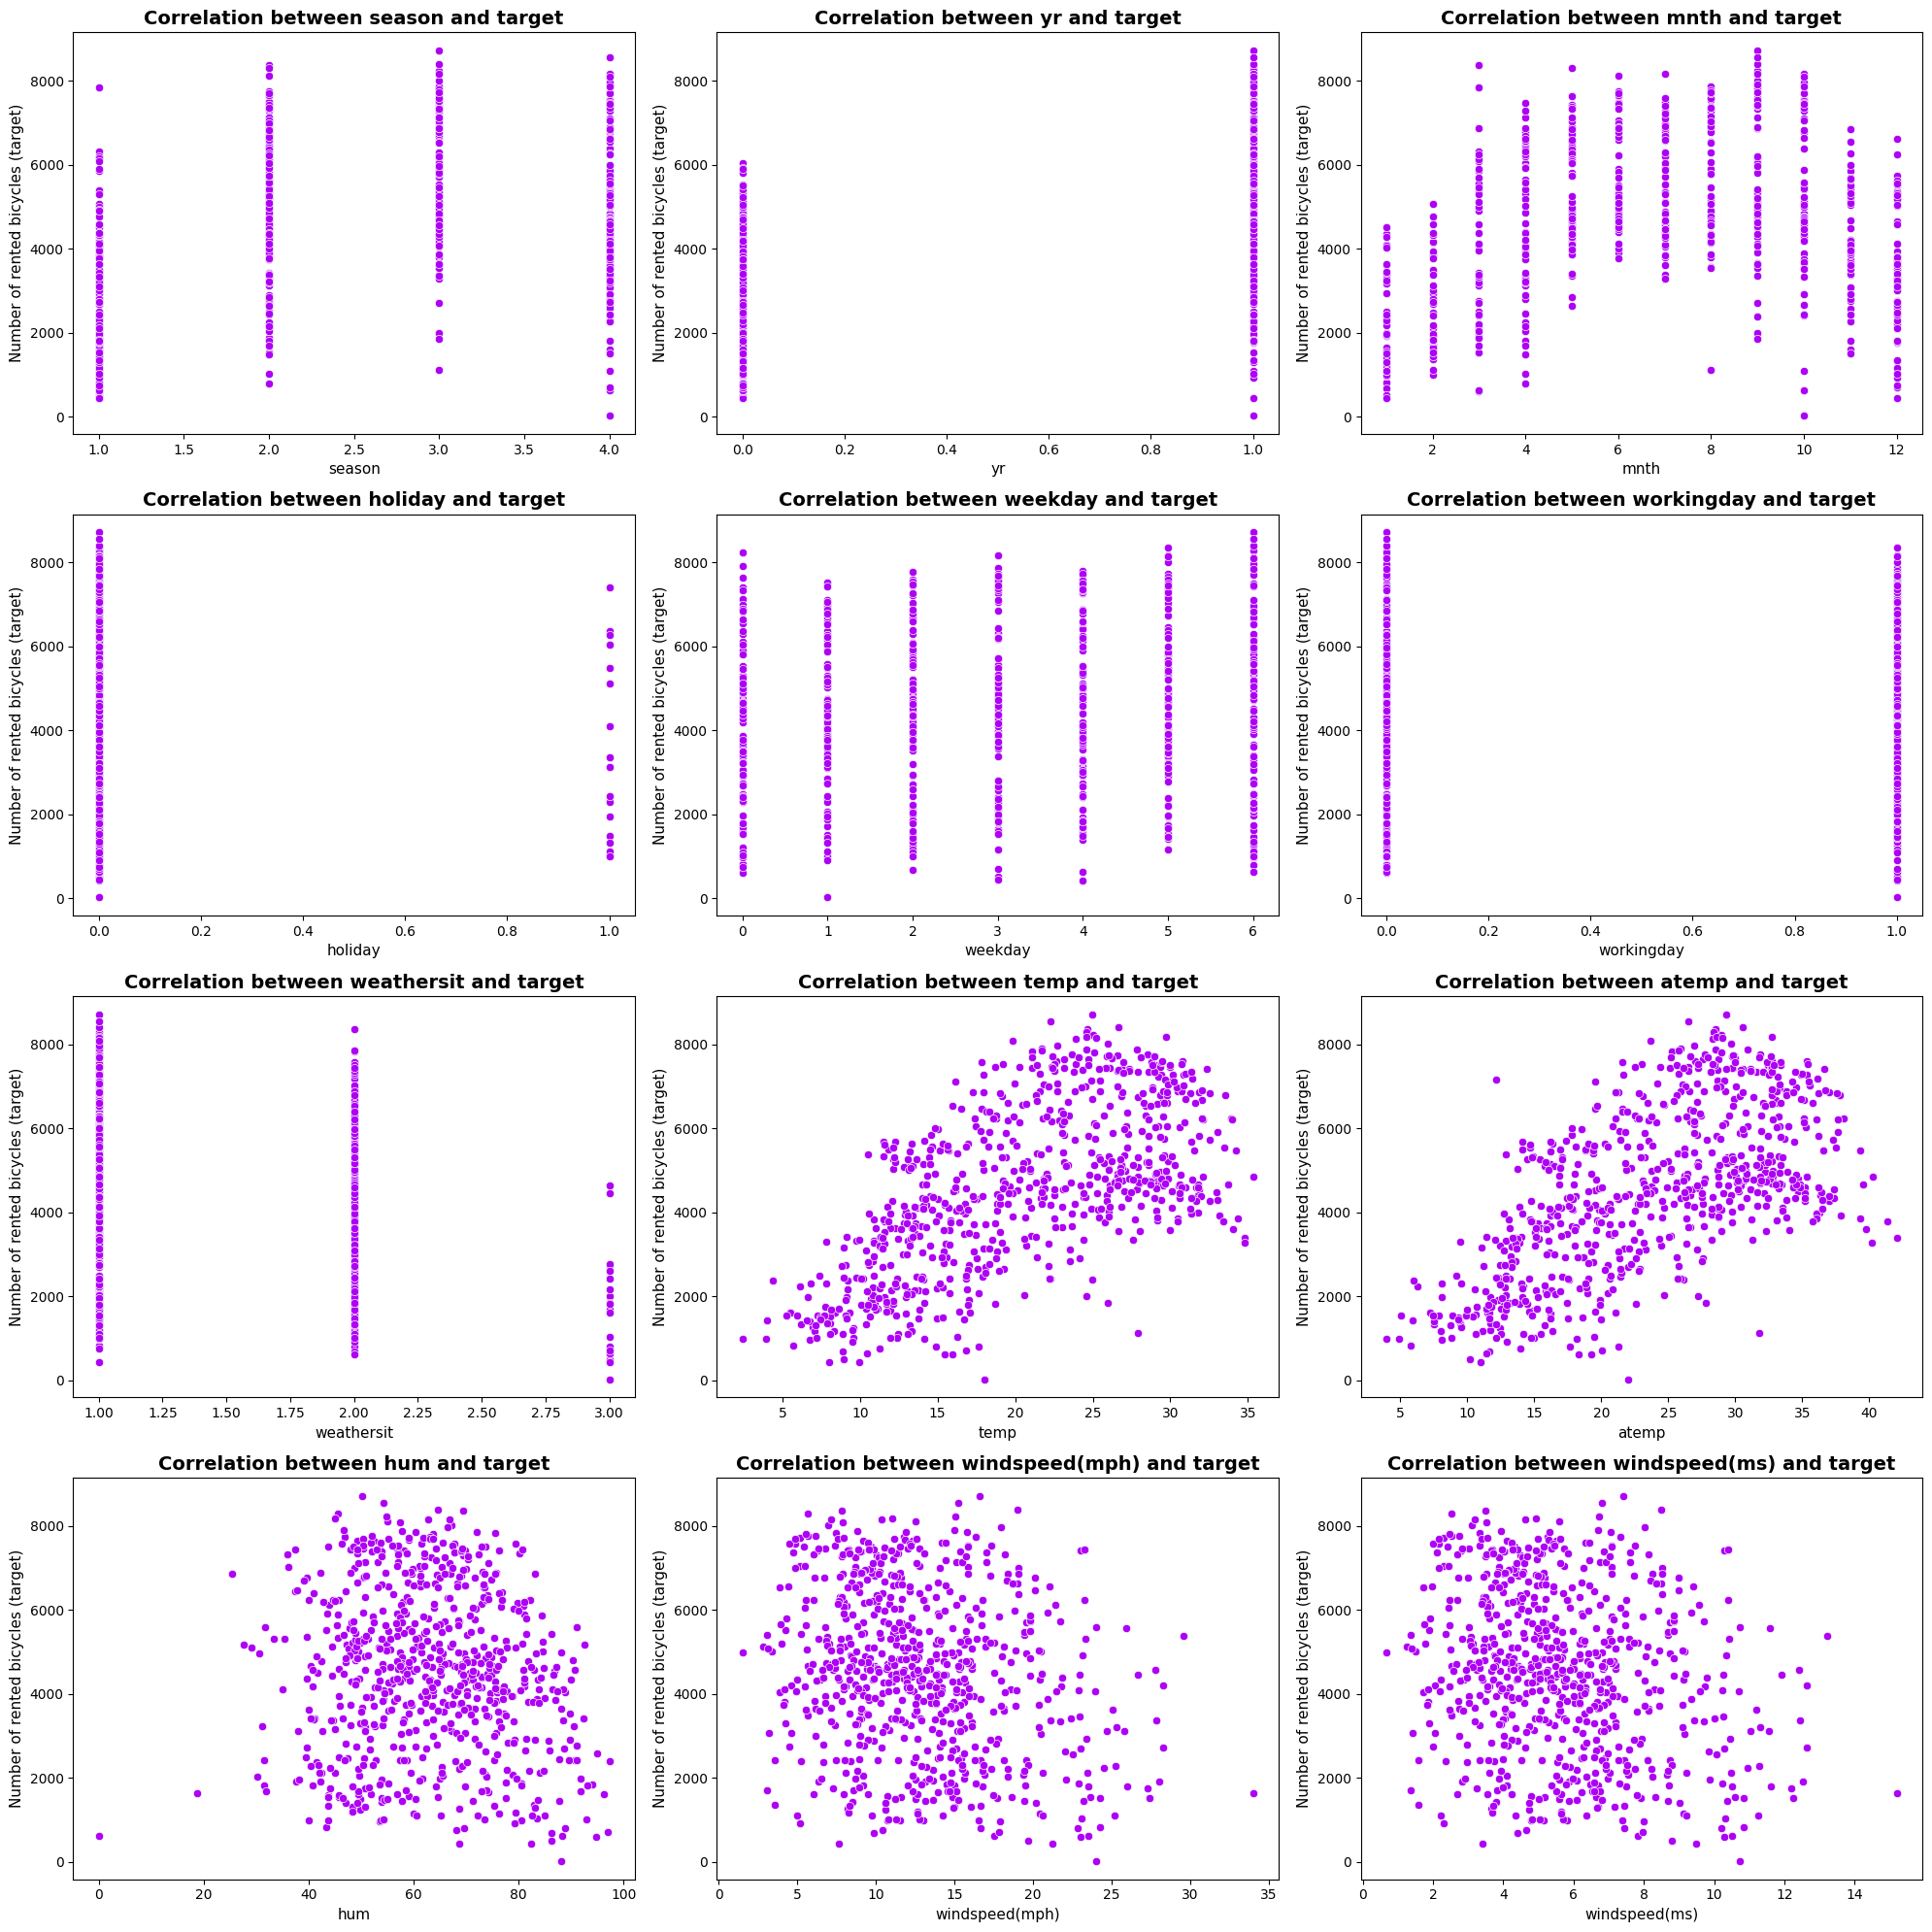

In [ ]:
fig = plt.figure(figsize = (20, 20))
gr = gridspec.GridSpec(4, 3)
features = df.columns.values
for feature, grd in zip(features, itertools.product([0, 1, 2, 3], [0, 1, 2])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.scatterplot(x=df[feature], y=df[target], color='#AD00F5')
    ax.set_title(f'Correlation between {feature} and target', fontsize = 14, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 11)
    ax.set_ylabel('Number of rented bicycles (target)', fontsize = 11)
fig.tight_layout()
plt.show()

__д) [5 баллов]__ Каков характер зависимости числа прокатов от месяца? От каких признаков спрос зависит линейно?

__Ответ:__  В теплые месяцы (май-октябрь) количество арендованных велосипедов растет, а в холодные - падает. Зависимость похожа на толстую параболу.

Больше всего на линейную зависимость похожи зависимости спроса между фактической и ощущаемой температурой, но все равно здесь очень сильный разброс значений.

__е) [5 баллов]__ Постройте гистограммы для всех непрерывных переменных. Что можете сказать о выбросах?

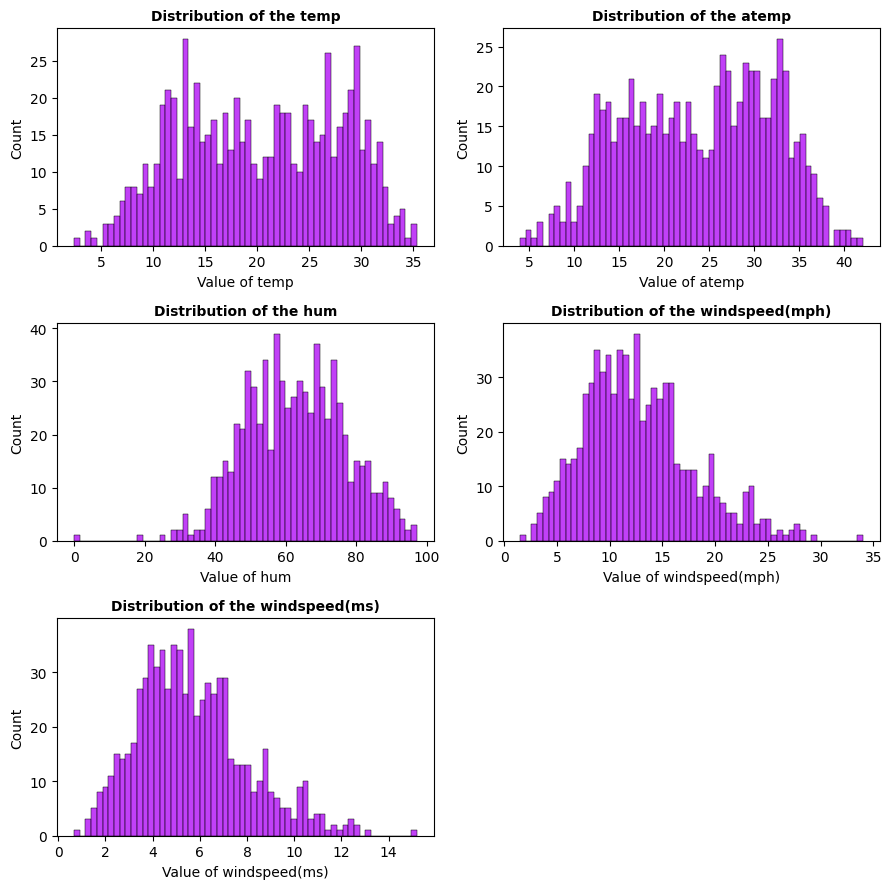

In [ ]:
fig2 = plt.figure(figsize = (9, 9))
gr2 = gridspec.GridSpec(3, 2)

for feat, grd in zip(var_real, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr2[grd[0], grd[1]])
    ax = sns.histplot(x=df[feat], color='#AD00F5', bins=60)
    ax.set_title(f'Distribution of the {feat}', fontsize = 10, fontweight='heavy')
    ax.set_xlabel(f'Value of {feat}', fontsize = 10)
    ax.set_ylabel('Count', fontsize = 10)
fig2.tight_layout()
plt.show()

**Ответ**: У признаков влажность, скорость ветра довольно много выбросов (много колонок в гистограммах, которые далеко от основной массы). У температуры более сжатое распределение, нет таких длинных хвостов, но, возможно, есть некоторые выбросы.

__ж) [5 баллов]__ Постройте между непрерывными признаками корреляционную матрицу. Нарисуйте её. Какие признаки, скорее всего, неинформативны? Почему они на ваш взгляд такие?

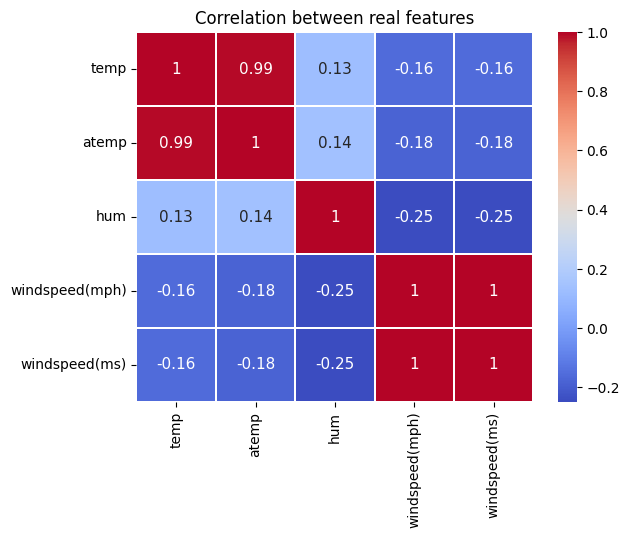

In [ ]:
sns.heatmap(df[var_real].corr(), cmap = 'coolwarm', annot=True, annot_kws={'size': 11}, linewidth=0.01)
plt.title('Correlation between real features')
plt.show()

__Ответ:__ Два признака со скоростью ветра имеют корреляцию 1, так как один это просто перевод в другую систему измерений другого, поэтому любой из них можно выкинуть, он не будет нести какой-либо дополнительной информации.

Такая же ситуация с температурами: в основном они показывают плюс минус одно значение (вряд ли фактическая температура будет +20, а ощущаемая -10). На ощущаемую температуру могут влиять другие признаки (типа ветер, влажность), поэтому он может быть менее информативен, чем фактическая температура (как комбинация нескольких существующих признаков).

__з) [5 баллов]__ Постройте для всех категориальных переменных _countplot_. Что интересного вы видите в распределеии этих признаков?  Встречаются ли слишком обширные категории, в которых очень маленькие части нам придётся объединять в категорию "другое"?

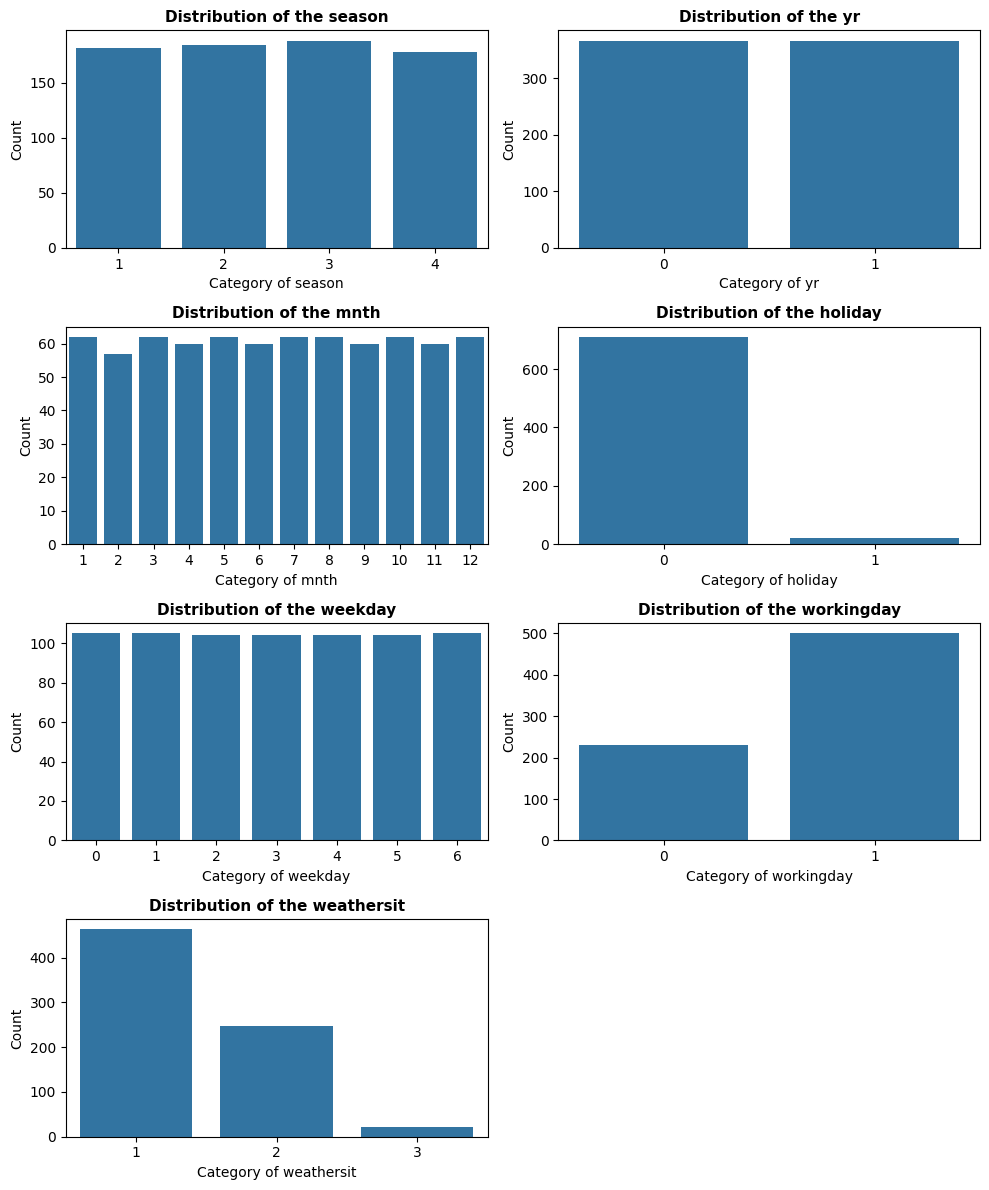

In [ ]:
fig3 = plt.figure(figsize = (10, 12))
gr3 = gridspec.GridSpec(4, 2)

for feat, grd in zip(var_cat, itertools.product([0, 1, 2, 3], [0, 1])):
    ax = plt.subplot(gr3[grd[0], grd[1]])
    ax = sns.countplot(x=df[feat])
    ax.set_title(f'Distribution of the {feat}', fontsize = 11, fontweight='heavy')
    ax.set_xlabel(f'Category of {feat}', fontsize = 10)
    ax.set_ylabel('Count', fontsize = 10)
fig3.tight_layout()
plt.show()

__Ответ:__  Почти все признаки распределены равномерно по группам за исключением индикатора того, что это праздничный день, рабочий день (потому что в целом непраздничных и нерабочих дней меньше), их никак не объеденить в категорию "другое". Также оценка благоприятности погоды неравномерно распределено, значения "4" вовсе нет, но не очень хорошо их будет объединять в группу "другое", тк это порядковый признак.

__и) [5 баллов]__  Сделайте OHE-кодирование. Сколько свежих OHE-признаков у нас появилось?

In [ ]:
df_ohe = pd.get_dummies(data=df, columns=var_cat)
print(f'Появилось {df_ohe.shape[1] - df.shape[1] + var_cat.shape[0]} OHE признака; в целом кол-во признаков изменилось на {df_ohe.shape[1] - df.shape[1]}')

Появилось 32 OHE признака; в целом кол-во признаков изменилось на 25


__к) [5 баллов]__   Некоторые из наших переменных могут вносить в спрос на велики квадратичный вклад. Например, температура.

Сначала, когда температура возрастает, люди выходят кататься охотнее, а потом, когда становится жарко, спрос резко падает. Так возникает параболическая зависимость.

Создайте для каждой действительной переменной из данных дополнительную переменную: её квадрат.

In [ ]:
df_ohe[['squared_temp', 'squared_atemp', 'squared_hum', 'squared_windspeed(mph)', 'squared_windspeed(ms)']] = (df_ohe[var_real] ** 2).values
df_ohe.head()

,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt,season_1,season_2,season_3,season_4,...,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,squared_temp,squared_atemp,squared_hum,squared_windspeed(mph),squared_windspeed(ms)
0,14.110847,18.18125,80.5833,10.749882,4.805490,985,True,False,False,False,...,True,False,False,True,False,199.116003,330.557852,6493.668239,115.559963,23.092738
1,14.902598,17.68695,69.6087,16.652113,7.443949,801,True,False,False,False,...,True,False,False,True,False,222.087427,312.828200,4845.371116,277.292867,55.412371
2,8.050924,9.47025,43.7273,16.636703,7.437060,1349,True,False,False,False,...,False,True,True,False,False,64.817377,89.685635,1912.076765,276.779887,55.309860
3,8.200000,10.60610,59.0435,10.739832,4.800998,1562,True,False,False,False,...,False,True,True,False,False,67.240000,112.489357,3486.134892,115.343991,23.049580
4,9.305237,11.46350,43.6957,12.522300,5.597810,1600,True,False,False,False,...,False,True,True,False,False,86.587436,131.411832,1909.314198,156.807997,31.335472


__л) [5 баллов]__  Попробуйте придумать ещё какую-нибудь новую фичу (дополнительную переменную) для прогнозирования. Опишите какая за вашей фичёй стоит интуиция и почему это должно сработать при моделировании.

In [ ]:
# признак: является ли день нерабочим с хорошей погодой (weathersit = 1 or 2)
uslovie = (df_ohe['workingday_0'] == True) & ((df_ohe['weathersit_1'] == True) | (df_ohe['weathersit_2'] == True))
df_ohe['weekday_good_weather'] = 0
df_ohe.loc[uslovie, 'weekday_good_weather'] = 1

В нерабочие дни при хорошей погоде спрос на велосипеды будет скорее высокий, так как большее число людей предпочтут проводить выходные на улице, а не сидя дома. Тут объединены два фактора, которые должны положительно влиять на спрос, при этом они не совсем повторяют то, что уже есть, так как фактором хорошей погоды выступает и 1, и 2 у weathersit.

## 2. Обучение модели

__а) [10 баллов]__  Разбейте выборку на тренировочную и тестовую.

In [ ]:
y = df_ohe[target]
X = df_ohe.drop(target, axis=1)
from sklearn.model_selection import train_test_split
bins1 = np.linspace(np.min(y), np.max(y) + 1, 20)
y_binned = np.digitize(y, bins = bins1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y_binned, random_state=0)

__б) [10 баллов]__ Возьмите RMSE в качестве метрики качества. Для этого нужно написать свою функцию. Постройте наивный прогноз (среднее) и найдите для него RMSE.

In [ ]:
def rmse(y_real, y_test):
    rmse = np.sqrt(((y_real - y_test) ** 2).sum() / len(y_real))
    return rmse

In [ ]:
y_mean = y_train.mean()
y_naive_train = np.ones(len(y_train)) * y_mean
y_naive_test = np.ones(len(y_test)) * y_mean
print(f'RMSE с наивным прогнозом на трейне: {rmse(y_train, y_naive_train)}')
print(f'RMSE с наивным прогнозом на тесте: {rmse(y_test, y_naive_test)}')

RMSE с наивным прогнозом на трейне: 1930.666666022883
RMSE с наивным прогнозом на тесте: 1948.0114554651375


__в) [5 баллов]__ Запустите код с разбиением выборки на тренировочную и тестовую, подсчётом наивного прогноза и RMSE по нему несколько раз. НЕ НАДО НИЧЕГО КОПИРОВАТЬ. ПРОСТО ПЕРЕЗАПУСТИТЕ КОД ТРИ РАЗА. Меняется ли RMSE? Почему оно меняется? К чему плохому это может привести при обучении? Как это обычно исправляют?

__Ответ:__  RMSE не меняется, но он менялся бы, если бы я не указала random_state, который фиксирует разбиение (без указания данного параметра датасет каждый раз рандомно разбивается, из-за чего меняется среднее в трейне и, соответственно, ошибка).

Изменение ошибки говорит о том, что обучение модели зависит от того, какие объекты попали в тест, а какие в трейн, и это может повлиять на итоговый результат (так как могут попасться выбросы, которые сломают все на обучении, или же в тесте, из-за чего ошибка получится гигантской). Исправляют это кросс-валидацией, с помощью которой все объекты могут побывать и в трейне, и в тесте.

__г) [10 баллов]__ Оцените линейную регрессию. Насколько удалось улучшить качество прогнозирования в сравнении с наивным прогнозом?  Визуализируйте прогнозы функцией `plot_yreal_ypred`.

Что вы видите на этой визуализации? Проинтерпретируйте картинку.

__Ответ:__ Ошибка и на трейне, и на тесте сильно снизилась (более, чем в два раза), так как теперь мы по-умному подбираем коэффициенты, минимизируя ошибку на трейне.

Если смотреть на графики, в целом модель предсказывает не с сильно большим разбросом, но есть некоторые значения, которые очень сильно выбиваются из общей массы, особенно на тесте.

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
print(f'RMSE on train: {rmse(y_train, y_train_pred)}')
print(f'RMSE on test: {rmse(y_test, y_test_pred)}')

RMSE on train: 646.0007928923061
RMSE on test: 812.1099404031446


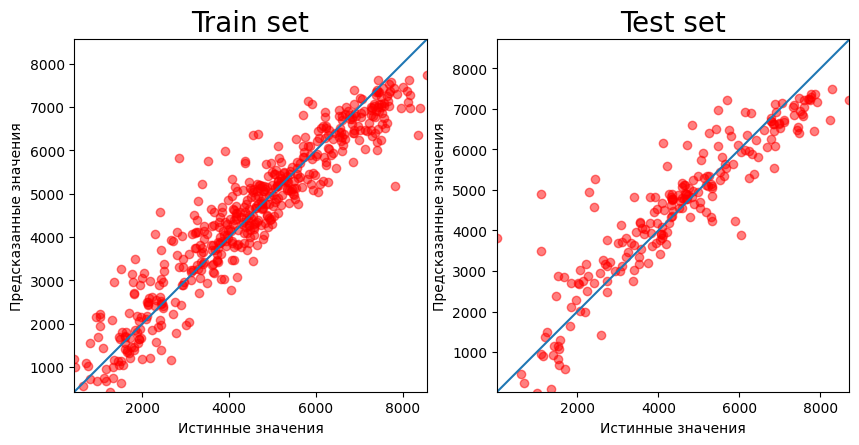

In [ ]:
plot_yreal_ypred(y_test, y_train, y_test_pred, y_train_pred)

__д) [10 баллов]__ Какими получились значения перед коэффициентами у вашей модели?  Как думаете, почему такое произошло?

__Ответ:__  Некоторые коэффициенты получились очень большими (миллиарды и триллионы), что скорее всего говорит о переобучении модели.

In [ ]:
display(pd.DataFrame(lr.coef_.reshape(1, -1), columns=X.columns.values))
print(f'Свободный коэффициент: {lr.intercept_}')

,temp,atemp,hum,windspeed(mph),windspeed(ms),season_1,season_2,season_3,season_4,yr_0,...,workingday_1,weathersit_1,weathersit_2,weathersit_3,squared_temp,squared_atemp,squared_hum,squared_windspeed(mph),squared_windspeed(ms),weekday_good_weather
0,639.588741,-251.662867,66.408445,-1.583813e+12,3.542989e+12,1.020114e+09,1.020115e+09,1.020115e+09,1.020116e+09,-1.682861e+08,...,9.465085e+07,-3.123029e+08,-3.123033e+08,-3.123042e+08,-11.544047,3.582449,-0.667114,3.114051e+10,-1.558324e+11,617.655223


Свободный коэффициент: -432083961.12006843


## 3. Бонус

__a) [2 балла]__ Обучите Lasso-регрессию. В качестве силы регуляризации возьмите $\alpha = 40$.

* Каким получилось качество прогноза?
* Что в модели произошло с коэффициентами?  

In [ ]:
from sklearn import linear_model
lasso = linear_model.Lasso(alpha=40)
lasso.fit(X_train, y_train)
y_lasso_train_pred = lasso.predict(X_train)
y_lasso_test_pred = lasso.predict(X_test)
print(f'RMSE on train: {rmse(y_train, y_lasso_train_pred)}')
print(f'RMSE on test: {rmse(y_test, y_lasso_test_pred)}')

RMSE on train: 764.4231017575092
RMSE on test: 816.0902164736767


In [ ]:
display(pd.DataFrame(lasso.coef_, index=X.columns.values))
print(f'Свободный коэффициент: {lasso.intercept_}')

,0
temp,4.447223e+02
atemp,0.000000e+00
hum,7.095211e+01
windspeed(mph),-2.972088e+01
windspeed(ms),-0.000000e+00
season_1,-5.721031e+02
season_2,-0.000000e+00
season_3,0.000000e+00
season_4,2.798830e+02
yr_0,-1.735620e+03


Свободный коэффициент: -468.73878888264426


__Ответ:__   Качество прогноза ухудшилось, так как был выбран слишком большой коэффициент регуляризации альфа, из-за чего многие признаки занулились (так как регуляризация в данном случае сильно влияет на значение ошибки, и модели лучше занулить все коэффициенты, чтобы получить наименьшую ошибку).

__б) [0 баллов]__  Изучите код в этом пункте и прочитайте выводы. Подумайте об этом.

В случае линейных моделей, обычно, используют два вида регуляризации: Ridge и Lasso. Первая прибавляет к MSE квадраты коэффицентов, а вторая модули. Давайте посмотрим какая между ними разница.

In [ ]:
from sklearn.linear_model import Lasso, Ridge  # подгружаем модели

Обучим много-много моделей с разными силами регуляризации $\alpha$ и посмотрим что получится.

In [ ]:
alphas = np.arange(1, 100, 2)   # задали диапазон для силы регуляризатора

# матрицы для весов перед коэффициентами (число регрессоров)*(число признаков)
coefs_lasso = np.zeros((alphas.shape[0], X.shape[1]))
coefs_ridge = np.zeros((alphas.shape[0], X.shape[1]))

i = 0
for alph in alphas:
    rg = Ridge(alpha=alph)  # для каждого alph обучаем модель
    ls = Lasso(alpha=alph)
    rg.fit(X,y)
    ls.fit(X,y)
    coefs_ridge[i] = rg.coef_  # и запоминаем коэффициенты
    coefs_lasso[i] = ls.coef_
    i += 1

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.748e+08, tolerance: 2.740e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.060e+08, tolerance: 2.740e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.612e+06, tolerance: 2.740e

В отличие от L2-регуляризации (Ridge), L1 (Lasso) обнуляет веса при некоторых признаках. Давайте пронаблюдаем, как меняются веса при увеличении коэффициента регуляризации $\alpha$ (в лекции коэффициент при регуляризаторе мог быть обозначен другой буквой).

Text(0.5, 1.0, 'Ridge')

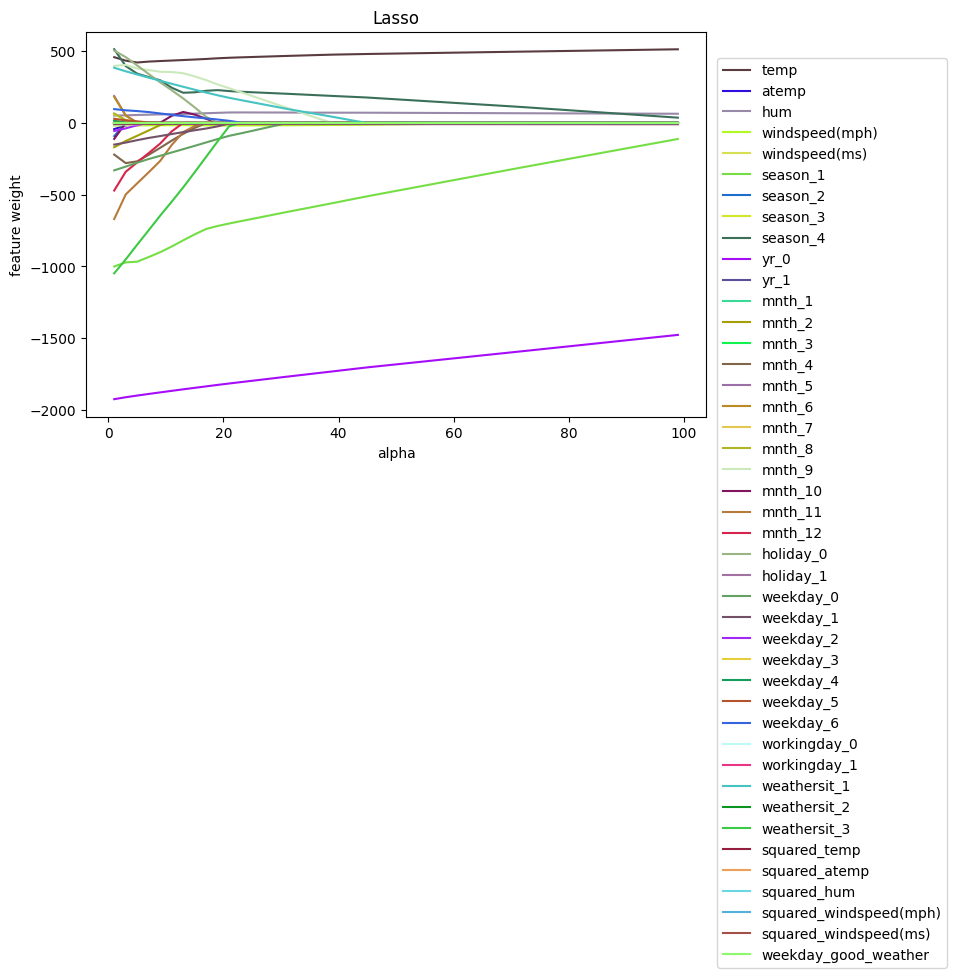

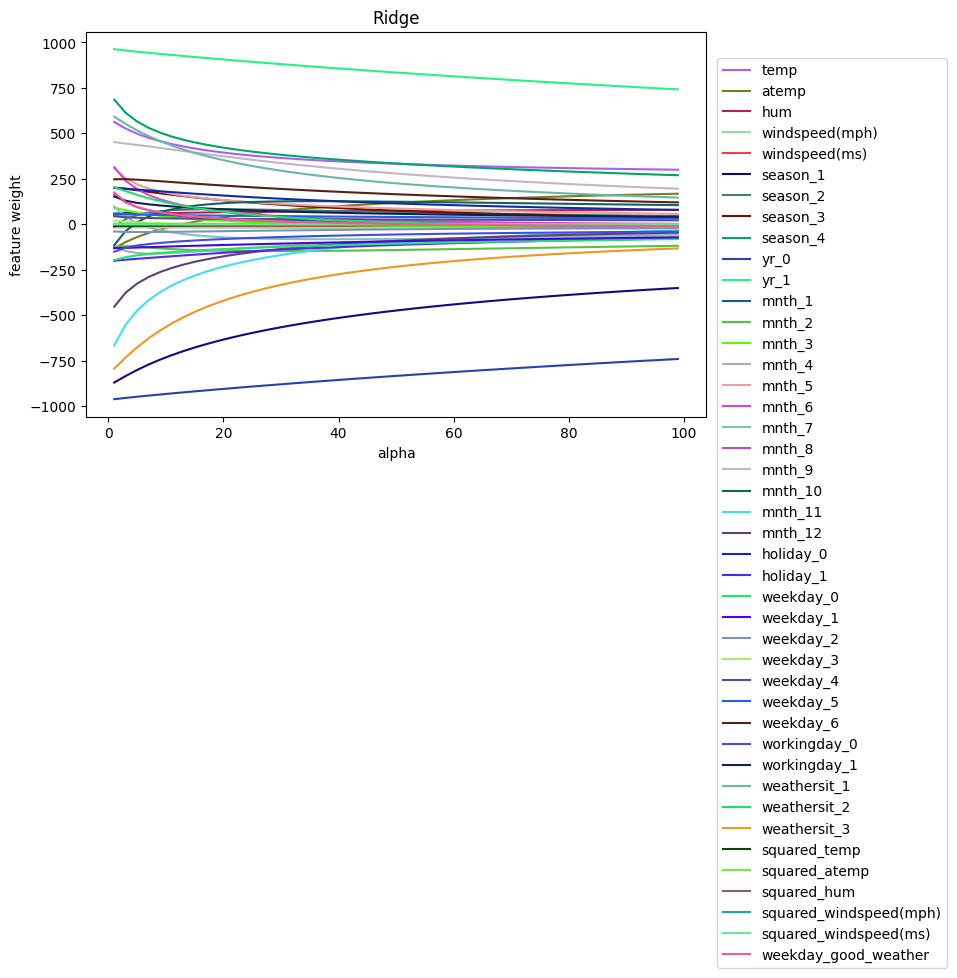

In [ ]:
plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_lasso.T, X.columns.values):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_ridge.T, X.columns.values):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

Картинки вышли красивыми. Обратите внимание, что регуляризатор Lasso агрессивнее уменьшает веса. Подумайте с чем это связано. Если делать `alpha` очень большим, веса зануляются. В случае Ridge такого не происходит. Веса становятся всё ближе к нулю, но зануления не происходит.  Из-за того, что Lasso зануляет некоторые признаки, его можно использовать для отбора самых важных признаков. Дальше будем работать именно с ним.

Итак, мы видим, что при изменении `alpha` модель по-разному подбирает коэффициенты признаков. Нам нужно выбрать наилучшее `alpha`. Для этого, во-первых, нам нужна метрика качества. Будем использовать в качестве метрики сам оптимизируемый функционал метода наименьших квадратов, то есть MSE (Mean Square Error).

Во-вторых, нужно понять, на каких данных эту метрику считать. Нельзя выбирать `alpha` по значению MSE на обучающей выборке, потому что тогда мы не сможем оценить, как модель будет делать предсказания на новых для нее данных. Если мы выберем одно разбиение выборки на обучающую и тестовую, то настроимся на конкретные "новые" данные, и вновь можем переобучиться.

Именно такую настройку вы наблюдали выше, когда запускали код с наивным прогнозом много раз подряд. Поэтому будем делать несколько разбиений выборки, на каждом пробовать разные значения `alpha`, а затем усреднять MSE. Удобнее всего делать такие разбиения кросс-валидацией, то есть разделить выборку на $K$ частей, или блоков, и каждый раз брать одну из них как тестовую, а из оставшихся блоков составлять обучающую выборку.

Подбирать параметр `alpha` в `sklearn` совсем просто: для этого есть `GridSearchCV`. Мы уже сталкивались с примером применения этой функции на семинаре. Попробуйте с помощью неё перебрать список из альф и подыскать оптимальное. Параметр cv отвечает за то, на сколько частей делится выборка. Поставьте `cv=5`. Также укажите параметр `scoring = neg_mean_squared_error`. Это задаст функцию потерь, на которую будет ориентироваться `GridSearchCV` при переборе. Назовите переменную, в которой будет находиться перебор __grid_cv_lasso.__

__в) [2 балла]__ Подберите для Lasso-регрессии с помощью поиска по решётке оптимальное значение $\alpha$.  Каким оказалось это значение?


In [ ]:
from sklearn.model_selection import GridSearchCV
alphas2 = np.linspace(0, 10, 200)
searcher = GridSearchCV(
    Lasso(max_iter=100000), [{"alpha": alphas2}],
    scoring="neg_mean_squared_error", cv=5
)
searcher.fit(X_train, y_train)
best_alpha = searcher.best_params_["alpha"]

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.329e+07, tolerance: 1.409e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e

Лучшая альфа = 1.306532663316583


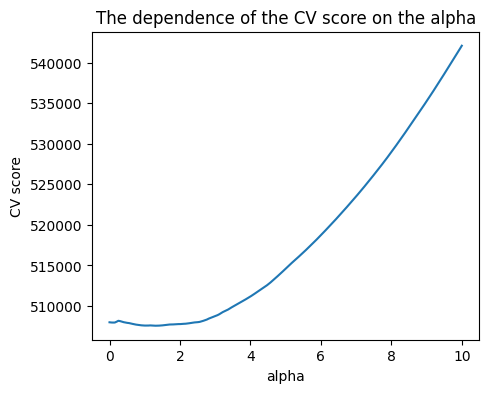

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(alphas2, -searcher.cv_results_["mean_test_score"])
plt.xlabel("alpha")
plt.ylabel("CV score")
plt.title('The dependence of the CV score on the alpha');
print(f'Лучшая альфа = {best_alpha}')

__г) [2 балла]__ Каким получается качество прогноза для модели с оптимальным значением $\alpha$?

In [ ]:
lasso_best = linear_model.Lasso(alpha=best_alpha)
lasso_best.fit(X_train, y_train)
y_train_best = lasso_best.predict(X_train)
y_test_best = lasso_best.predict(X_test)
print(f'RMSE on train: {rmse(y_train, y_train_best)}, изменение на {(rmse(y_train, y_train_best) - rmse(y_train, y_train_pred))/rmse(y_train, y_train_pred)*100} %')
print(f'RMSE on test: {rmse(y_test, y_test_best)}, изменение на {(rmse(y_test, y_test_best) - rmse(y_test, y_test_pred))/rmse(y_test, y_test_pred)*100} %')

RMSE on train: 648.8938852987295, изменение на 0.44784657205610023 %
RMSE on test: 799.7984718973233, изменение на -1.515985446466725 %


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.107e+08, tolerance: 1.905e+05
  model = cd_fast.enet_coordinate_descent(


__д) [2 балла]__ Наконец, как принято в анализе данных, давайте проинтерпретируем результат. Проинтерпретируйте последнюю обученую модель. У каких признаков наибольшие положительные коэфициенты? У каких наибольшие отрицательные? Логично ли утверждать, что чем больще/меньше эти признаки, тем выше/ниже спрос на велосипеды? Какие коэффициенты занулились?

In [ ]:
display(pd.DataFrame(lasso_best.coef_, index=X.columns.values))
print(f'Свободный коэффициент: {lasso.intercept_}')

,0
temp,4.360598e+02
atemp,-6.705142e+01
hum,6.591941e+01
windspeed(mph),-3.312530e+01
windspeed(ms),-0.000000e+00
season_1,-1.030367e+03
season_2,-9.555420e+01
season_3,4.295442e+01
season_4,5.556261e+02
yr_0,-1.953394e+03


Свободный коэффициент: -468.73878888264426


In [ ]:
max_pos_coef = np.argsort(-lasso_best.coef_)[:7]
max_neg_coef = np.argsort(lasso_best.coef_)[:7]
pos = dict(zip(X.columns.values[max_pos_coef], lasso_best.coef_[max_pos_coef]))
neg = dict(zip(X.columns.values[max_neg_coef], lasso_best.coef_[max_neg_coef]))
print('Топ-5 признаков с наибольшими положительными признаками:')
display(pos)
print('\n Топ-5 признаков с наибольшими отрицательными признаками:')
display(neg)

Топ-5 признаков с наибольшими положительными признаками:


{'holiday_0': 793.4021355526351,
 'season_4': 555.6261351918331,
 'temp': 436.05984286670304,
 'weathersit_1': 384.43277230458983,
 'mnth_9': 370.72681793722194,
 'mnth_5': 312.45645141967765,
 'mnth_6': 204.88649296672432}


 Топ-5 признаков с наибольшими отрицательными признаками:


{'yr_0': -1953.3941818618562,
 'season_1': -1030.3669640831718,
 'weathersit_3': -986.3117100251204,
 'mnth_12': -564.1367238412464,
 'mnth_11': -562.8453945715662,
 'weekday_0': -510.15949374876675,
 'mnth_4': -172.97677088500154}

__Ответ:__  Из наиболее весомых признаков с положительными коэффициентами самыми неочевидными стали индикатор того, что сейчас праздник: возможно, люди берут в аренду велосипед, чтобы доехать до работы или метро, как у нас электросамокаты.

Помимо этого зима сильно положительно влияет на спрос: может быть, в в исследуемом городе/ стране климат отличается от нашего (типа Австралия), и зимой там благоприятная погода для аренды великов, при этом лето отрицательно влияет на спрос, что подтверждает гипотезу. Но тогда получается несостыковка с прямой зависимостью от месяца 5, 6 и 9. Остальные признаки в целом логчины: температура и в целом хорошая погода положительно влияют на спрос.

С отрицательно влияющими признаками тоже интересная история: 11 и 12 месяц вносят большой отрицательный вклад. Предположу, что таким образом в модели взаимоуничтожается положительное влияние зимы, и в итоге она вносит отрицательный или просто очень маленький положительный вклад.

2011 год, видимо, был какой-то очень неблагоприятный, может были какие-то катаклизмы, кризис или что-то такое. Весна также сильно отрицательно влияет на спрос, опять же из-за возможных особенностей климата. Наличие плохой погоды (weathersit_3) логично плохо влияет на желание покататься на велосипеде (люди предпочитают другие виды передвижения или досуга).

Все остальные признаки подтверждают, что чем лучше условия для катания на великов, тем выше спрос: температура (положительное влияние), скорость ветра (отрицательная зависимость), время года, наличие праздника (если принять предыдущие предположения).

Однако фактическая температура влияет положительно, но ощущаемая отрицательно. Так как по модулю у второго признака коэффициент меньше, чем у первого, возможно влияение первого взаимоуничтожается вторым.

Занулились признаки скорость метров в секуду и его квадрат: это хорошо, так как это по сути тот же признак, что в милях, просто в другой системе измерений. Также занулился 2012 год, 7 и 10 месяц, weekday_3, weekday_4, weathersit_2.

__е) [2 балла]__ В прошлой домашке, когда мы придумывали фичи, мы предположили, что спрос на велосипеды зависит от скорости ветра квадратично, по параболе. Подтвердилось ли это предположение?

__Ответ:__  Вообще предполагалась такая зависимость у температуры, поэтому напишу про нее. У квадрата температуры коэффициент почти -7, у температуры без квадрата 436. Это похоже на параболу ветвями вниз, поэтому можно говорить о той параболической зависимости, о которой писали в 1 части.